# EDA for better understanding the data
##### The purpose of this EDA is to understand baseline behavior of the compressor during normal (fault-free) operation as a preparation for anomaly detection.

### Load data from .csv 

In [61]:
import pandas as pd

df = pd.read_csv("data/raw/MetroPT3(AirCompressor).csv")

### First look

In [62]:
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [90]:
df.tail()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516947,15169470,2020-09-01 03:59:50,-0.014,8.860,8.848,-0.022,8.864,59.475,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [91]:
df.shape

(1516948, 17)

#### Sort data by time 

In [92]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

#### Verification of data completness 

In [93]:
df[["timestamp", "Oil_temperature", "Motor_current"]].isna().sum()

timestamp          0
Oil_temperature    0
Motor_current      0
dtype: int64

#### Data quality check

In [94]:
df[["Oil_temperature", "Motor_current"]].describe().round(3)

,Oil_temperature,Motor_current
count,1516948.000,1516948.000
mean,62.644,2.050
std,6.516,2.302
min,15.400,0.020
25%,57.775,0.040
50%,62.700,0.045
75%,67.250,3.808
max,89.050,9.295


In [95]:
(df["timestamp"] == "").sum()

np.int64(0)

#### Validation of time differences

In [96]:
df["timestamp"].diff().value_counts().head(10)

timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
0 days 00:00:21         10
0 days 00:00:19          5
0 days 00:00:22          4
0 days 00:00:20          3
0 days 00:00:17          3
Name: count, dtype: int64

In [97]:
df["timestamp"].diff().value_counts().sort_index().tail(10)

timestamp
0 days 20:43:37    1
0 days 21:28:25    1
0 days 22:17:41    1
0 days 23:39:17    1
0 days 23:56:00    1
1 days 00:34:51    1
1 days 00:40:33    1
1 days 04:03:01    1
1 days 12:14:36    1
2 days 00:01:58    1
Name: count, dtype: int64

The dataset is sampled at approximately 10-second intervals and shows very high
local continuity. Over 99.9% of consecutive samples follow this pattern, with
minor timestamp jitter between 9 and 13 seconds.

A small number of isolated large gaps are present in the data. These gaps range
from several hours up to approximately two days and each occurs only once.
They most likely correspond to system downtime or maintenance periods rather
than random data loss.

### Data visualization

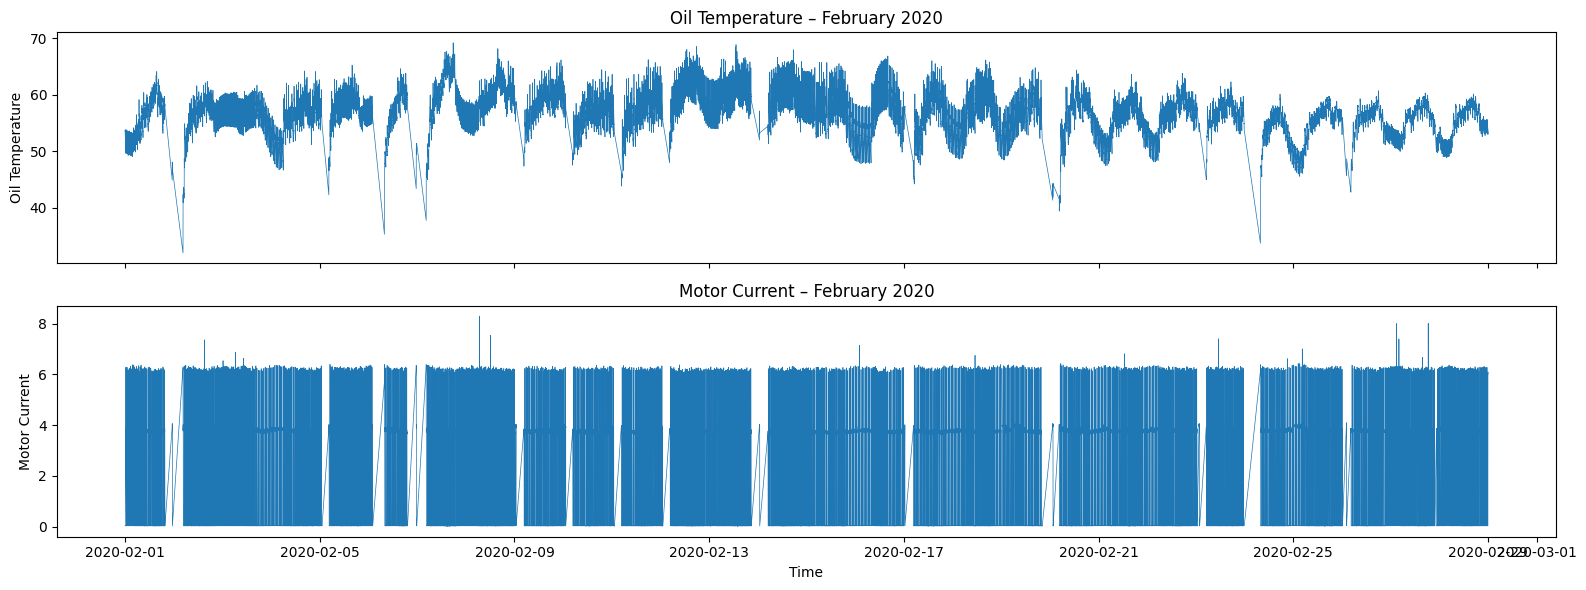

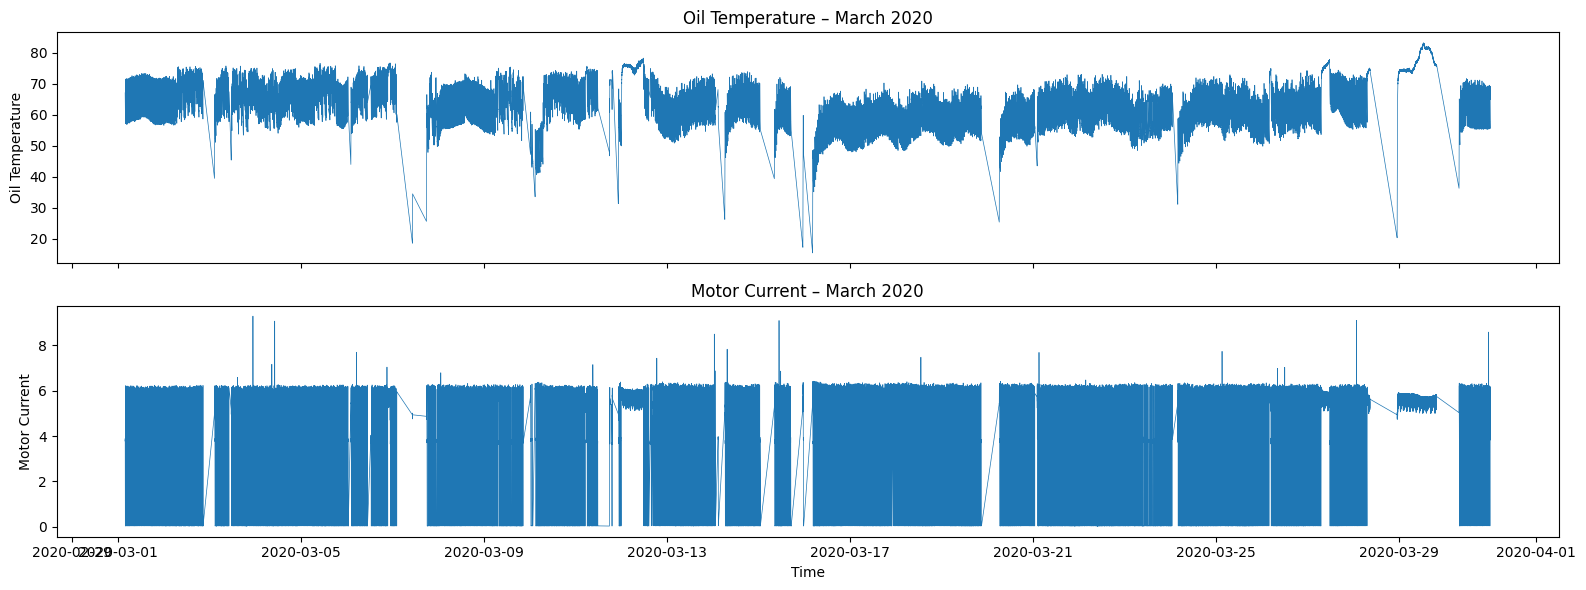

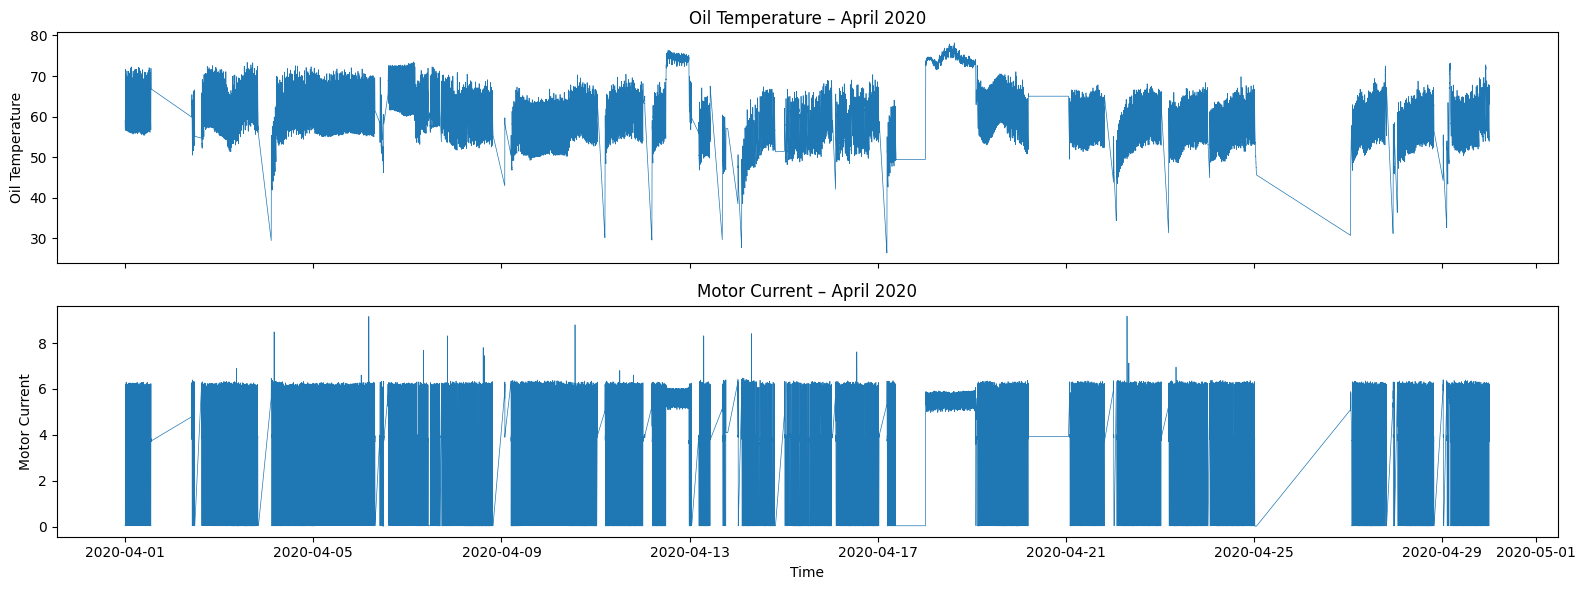

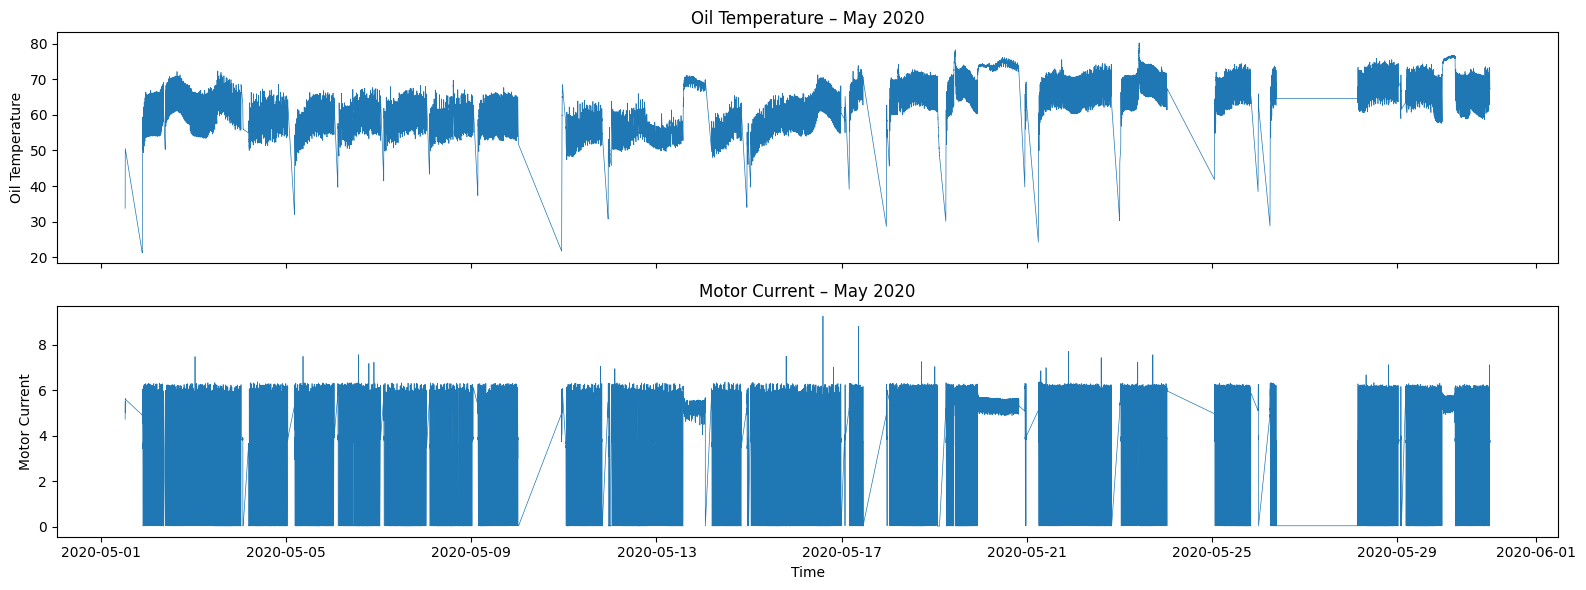

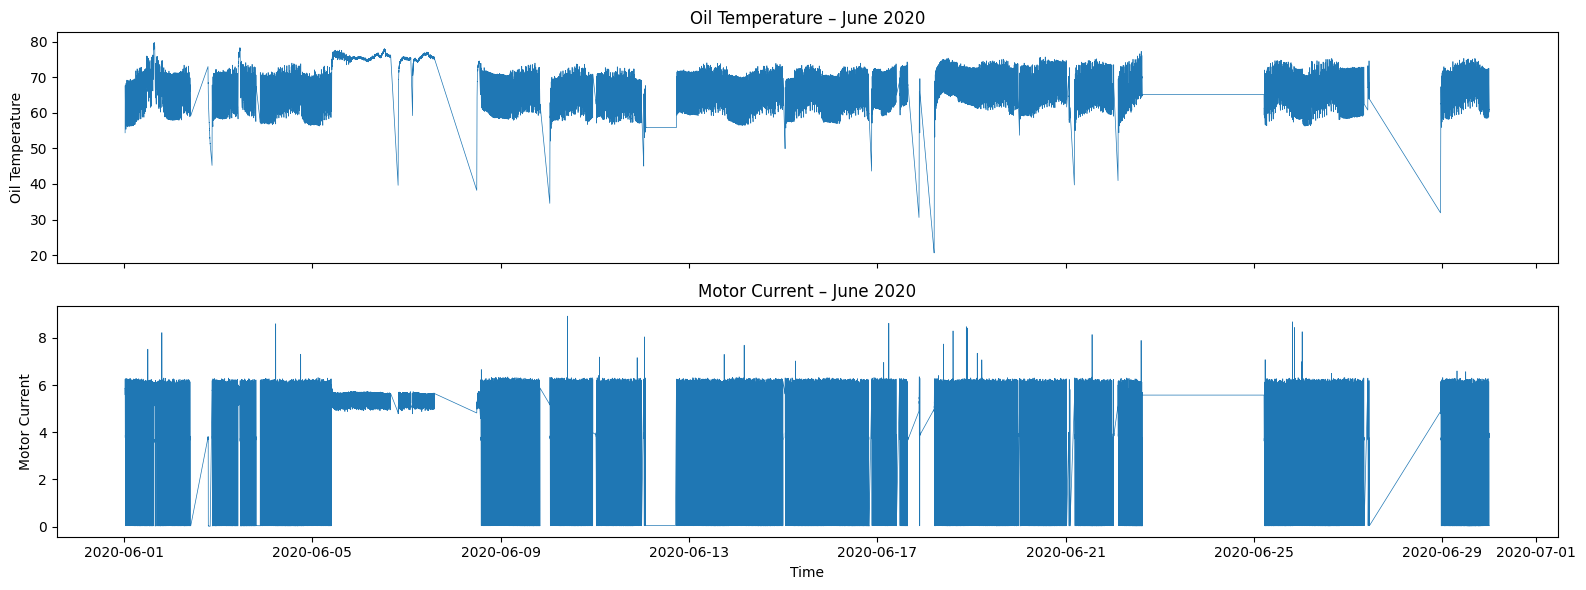

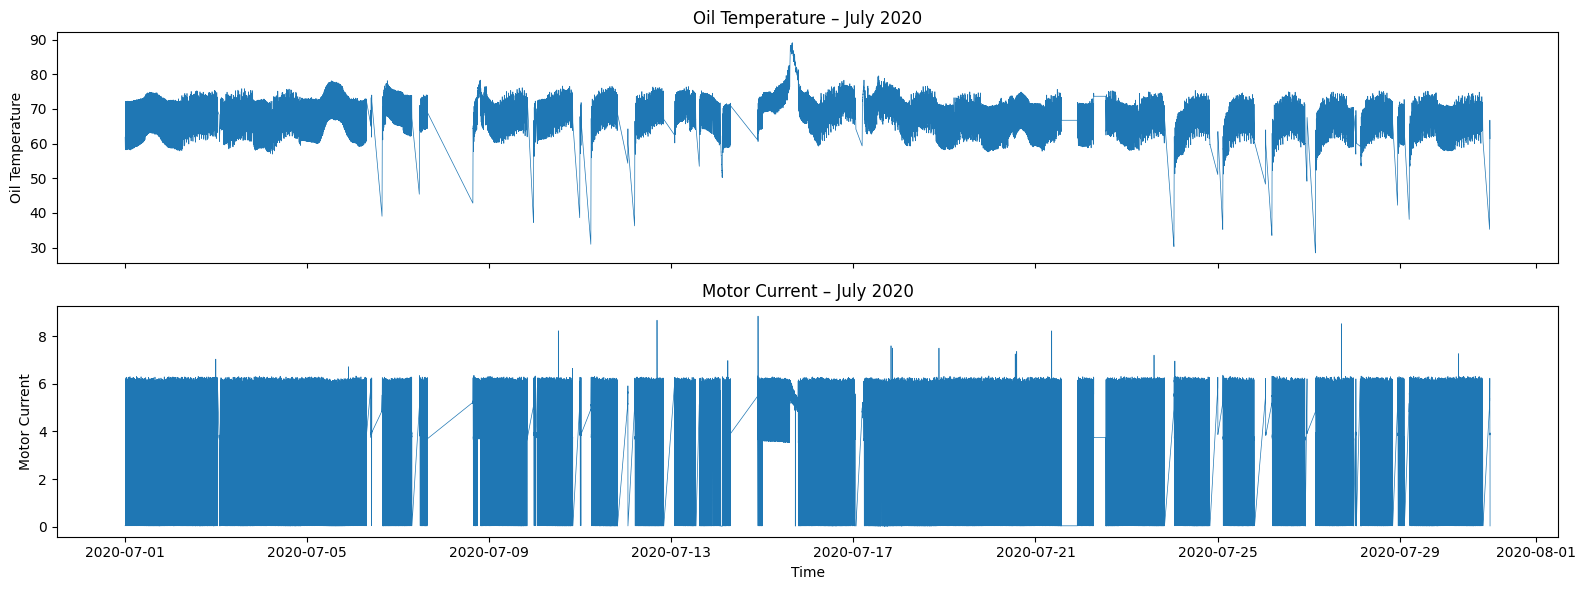

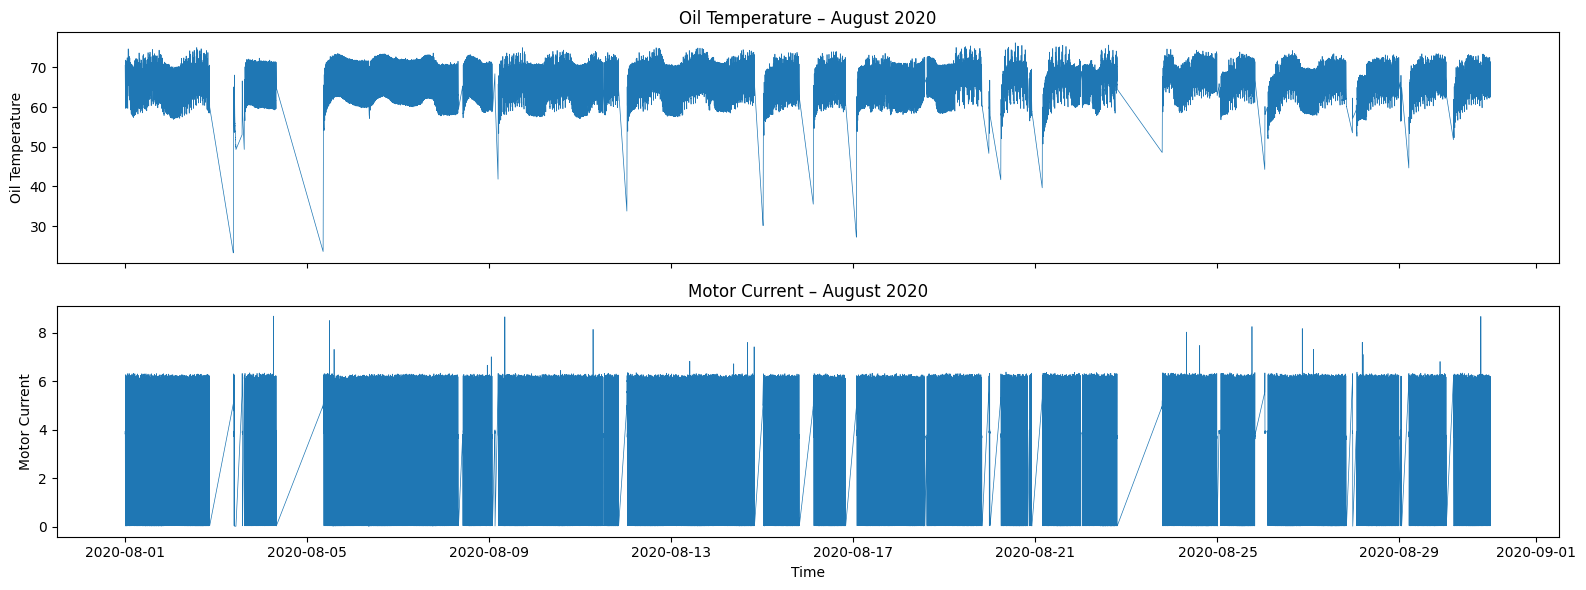

In [235]:
import matplotlib.pyplot as plt
import pandas as pd

months = pd.date_range(start="2020-02-01", end="2020-09-01", freq="MS")

for start in months[:-1]:
    end = start + pd.offsets.MonthEnd(1)

    df_month = df[(df["timestamp"] >= start) & (df["timestamp"] < end)]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    axes[0].plot(df_month["timestamp"], df_month["Oil_temperature"], linewidth=0.5)
    axes[0].set_title(f"Oil Temperature – {start.strftime('%B %Y')}")
    axes[0].set_ylabel("Oil Temperature")

    axes[1].plot(df_month["timestamp"], df_month["Motor_current"], linewidth=0.5)
    axes[1].set_title(f"Motor Current – {start.strftime('%B %Y')}")
    axes[1].set_ylabel("Motor Current")
    axes[1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()